# UPI Fraud Analytics — EDA & Anomaly Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/processed/upi_transactions_scored.csv', parse_dates=['timestamp'])
df.head()


,transaction_id,customer_id,timestamp,city,payment_mode,merchant_category,amount,hour,is_new_device,is_new_beneficiary,...,status,date,month,day_of_week,risk_flag,amount_iqr_anomaly,amount_zscore,high_amount_anomaly,risk_score,risk_band
0,TXN0000001,C000447,2025-01-13 10:24:00,Bengaluru,UPI Collect,Retail,362.08,10,0,0,...,Legitimate,2025-01-13,2025-01,Monday,False,0,-0.548634,0,0,Low
1,TXN0000002,C003870,2025-09-20 08:17:00,Lucknow,UPI QR,Retail,1345.33,8,0,0,...,Legitimate,2025-09-20,2025-09,Saturday,False,0,-0.034806,0,0,Low
2,TXN0000003,C003273,2025-03-19 21:08:00,Lucknow,UPI,Grocery,1007.85,21,0,0,...,Legitimate,2025-03-19,2025-03,Wednesday,False,0,-0.211167,0,0,Low
3,TXN0000004,C002195,2025-09-16 21:23:00,Mumbai,UPI Intent,Retail,683.10,21,0,0,...,Legitimate,2025-09-16,2025-09,Tuesday,False,0,-0.380875,0,0,Low
4,TXN0000005,C002166,2025-07-25 12:11:00,Mumbai,UPI,E-commerce,1464.06,12,0,0,...,Legitimate,2025-07-25,2025-07,Friday,False,0,0.027240,0,0,Low


In [2]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,20000,20000,TXN0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,20000,4901,C003816,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,20000,NaN,NaN,NaN,2025-07-02 15:04:33.438000,2025-01-01 00:06:00,2025-04-01 15:25:30,2025-07-03 13:24:30,2025-10-01 20:19:30,2025-12-30 23:47:00,NaN
city,20000,10,Chennai,2069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_mode,20000,4,UPI Collect,5041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_category,20000,6,Utilities,3417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,20000.0,NaN,NaN,NaN,1411.934605,17.09,433.145,845.63,1662.8375,55861.39,1913.627015
hour,20000.0,NaN,NaN,NaN,11.57115,0.0,6.0,12.0,18.0,23.0,6.929122
is_new_device,20000.0,NaN,NaN,NaN,0.0824,0.0,0.0,0.0,0.0,1.0,0.27498
is_new_beneficiary,20000.0,NaN,NaN,NaN,0.06195,0.0,0.0,0.0,0.0,1.0,0.241071


In [3]:
summary = df.groupby('city').agg(transactions=('transaction_id','count'), fraud_rate=('is_fraud','mean'), value=('amount','sum')).sort_values('fraud_rate', ascending=False)
summary


,transactions,fraud_rate,value
city,,,
Kolkata,2055,0.032603,2757604.86
Pune,1945,0.031877,2743332.64
Jaipur,2042,0.031832,2861699.93
Chennai,2069,0.025133,2860308.08
Bengaluru,1990,0.025126,2949408.35
Hyderabad,1989,0.024635,2810003.27
Delhi,1989,0.024133,2842708.76
Ahmedabad,1995,0.023559,2782719.66
Lucknow,1962,0.022936,2847944.36


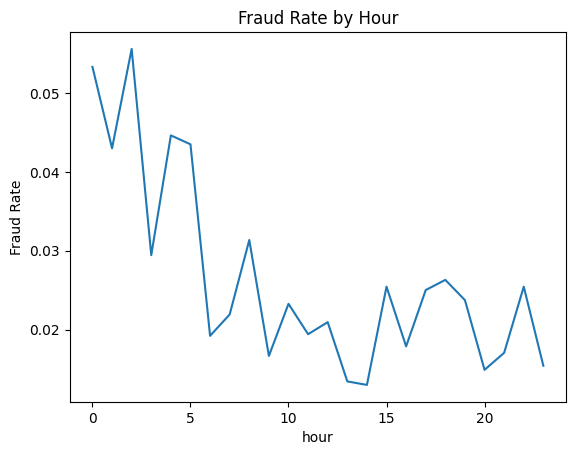

In [4]:
hourly = df.groupby('hour')['is_fraud'].mean()
hourly.plot(kind='line', title='Fraud Rate by Hour')
plt.ylabel('Fraud Rate')
plt.show()


## Next steps
Add your own hypotheses, charts, statistical tests and business conclusions.